<a href="https://colab.research.google.com/github/SHAKIL-25/Ai/blob/main/diabetes_prediction_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore", category=FutureWarning)

## Import Dataset

In [2]:
Diabetes_df=pd.read_csv('diabetes_prediction_dataset.csv')
Diabetes_df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# EDA (Exploratory Data Analysis)

## Data Understanding

In [3]:
Diabetes_df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [4]:
Diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
Diabetes_df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [6]:
Duplicate=Diabetes_df.duplicated().sum()
print("Duplicate Data in dataframe:", Duplicate)

Duplicate Data in dataframe: 3854


In [7]:
row, column=Diabetes_df.shape
print("Row of Dataset:", row)
print("Column of Dataset:", column)

Row of Dataset: 100000
Column of Dataset: 9


## Visualization

### Visualization of Patient's Gender

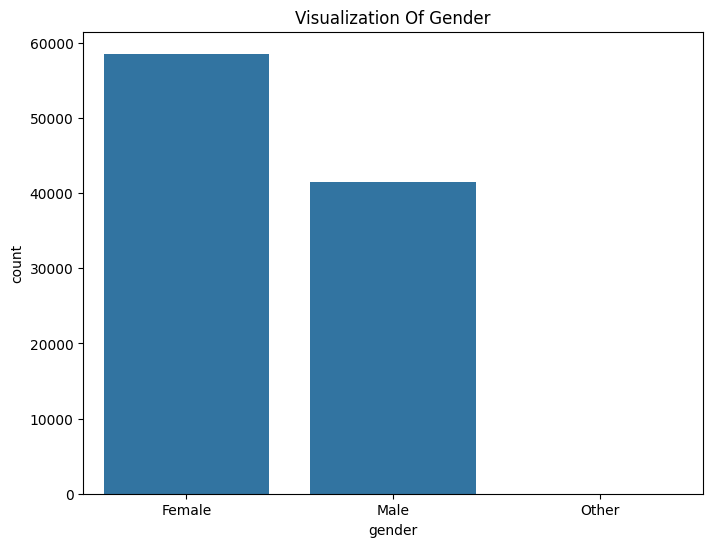

In [8]:
plt.figure(figsize=(8,6))
sns.countplot(data=Diabetes_df, x='gender')
plt.title('Visualization Of Gender')
plt.show()

### Visualization Of Patient's Smoking History

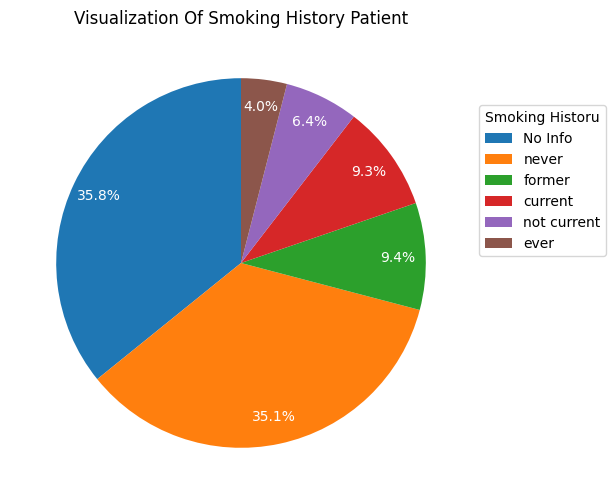

In [9]:
count_smoking= Diabetes_df['smoking_history'].value_counts()

plt.figure(figsize=(6,6))
wedges, texts, autotexts=plt.pie(
    count_smoking.values,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    textprops={'color':'white'}
)
plt.title('Visualization Of Smoking History Patient')
plt.legend(wedges, count_smoking.index, title="Smoking Historu", loc="lower left", bbox_to_anchor=(1,0.5))
plt.show()

### Visualization of Patient's Hypertension Status

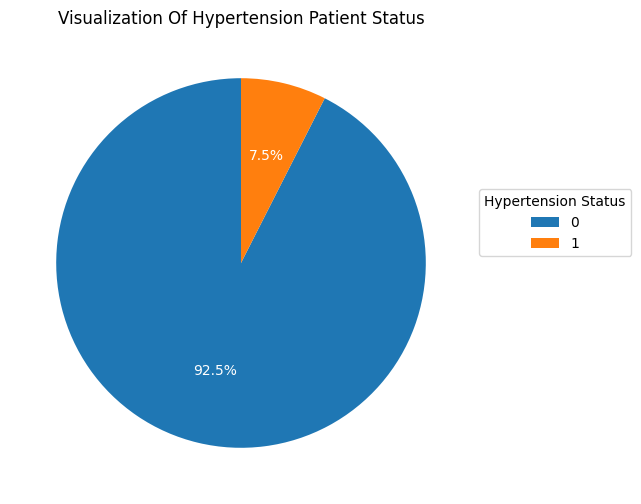

In [10]:
count_hypertension=Diabetes_df['hypertension'].value_counts()
plt.figure(figsize=(6,6))
wedges, texts, autotexts=plt.pie(
    count_hypertension.values,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.6,
    textprops={'color':'white'}
)

plt.title('Visualization Of Hypertension Patient Status')
plt.legend(wedges, count_hypertension.index, title="Hypertension Status", loc="lower left", bbox_to_anchor=(1,0.5))
plt.show()

### Visualization of Patient's Heart Disease status

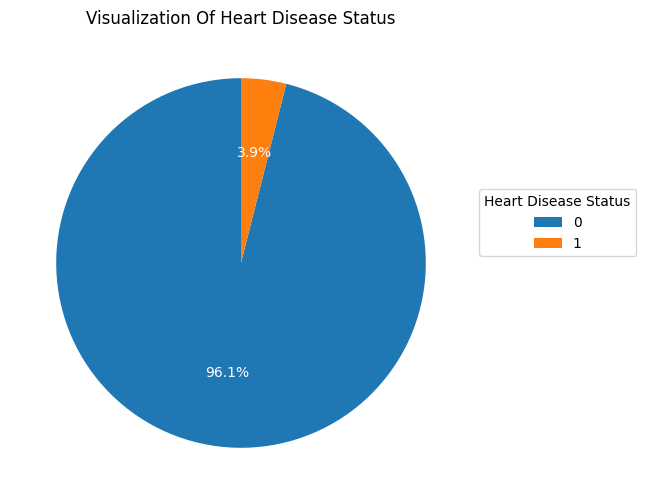

In [11]:
count_heart_disease=Diabetes_df['heart_disease'].value_counts()
plt.figure(figsize=(6,6))
wedges, texts, autotexts=plt.pie(
    count_heart_disease.values,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.6,
    textprops={'color':'white'}
)

plt.title('Visualization Of Heart Disease Status')
plt.legend(wedges, count_heart_disease.index, title="Heart Disease Status", loc="lower left", bbox_to_anchor=((1,0.5)))
plt.show()

### Visualization of Patient's Diabetes Status

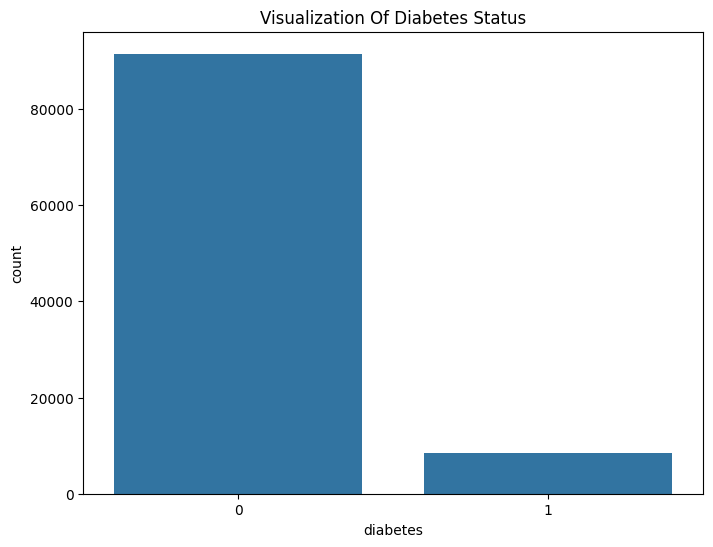

In [12]:
plt.figure(figsize=(8,6))
sns.countplot(data=Diabetes_df, x='diabetes')
plt.title("Visualization Of Diabetes Status")
plt.show()

### Visualization of Numeric Distribution Data

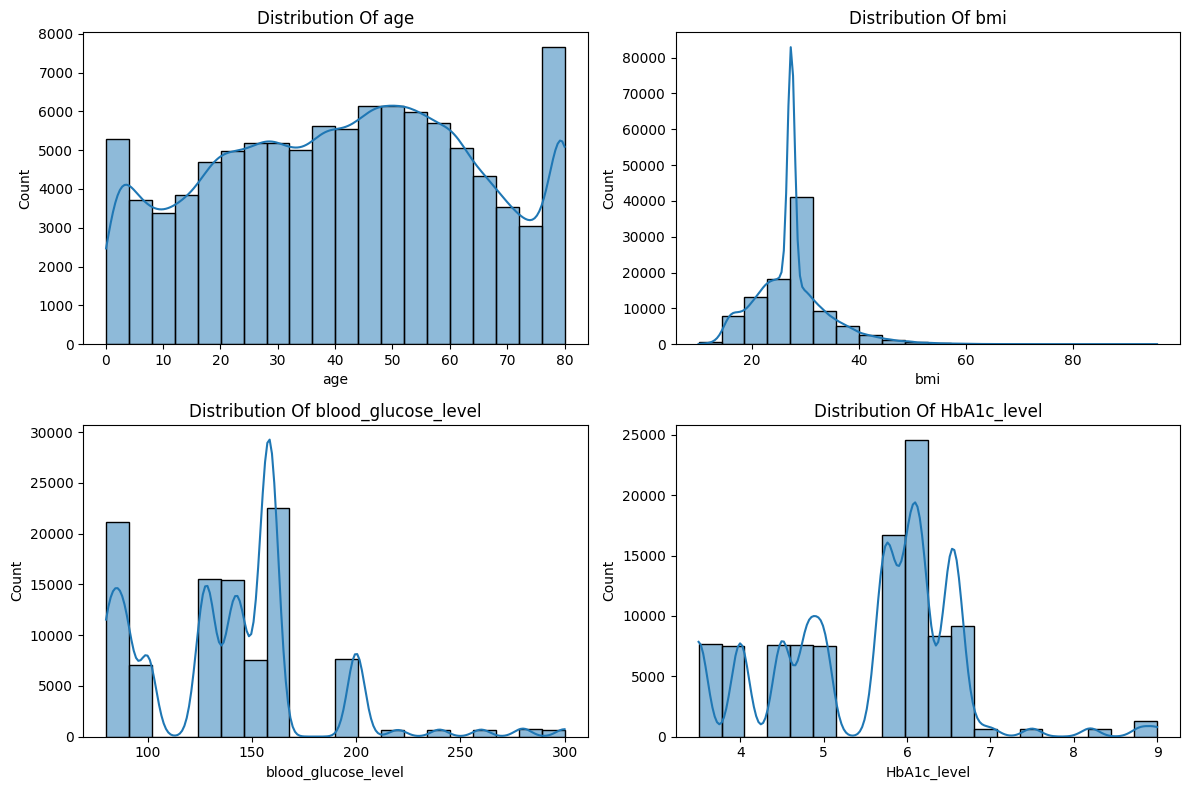

In [13]:
num_cat=['age', 'bmi','blood_glucose_level','HbA1c_level']

fig, axs=plt.subplots(2,2 ,figsize=(12,8))
axs=axs.flatten()

for i, col in enumerate(num_cat):
    sns.histplot(Diabetes_df[col], bins=20, kde=True, edgecolor='black', ax=axs[i])
    axs[i].set_title(f'Distribution Of {col}')
    axs[i].set_xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Visualization of Numerical Boxplot of The Data

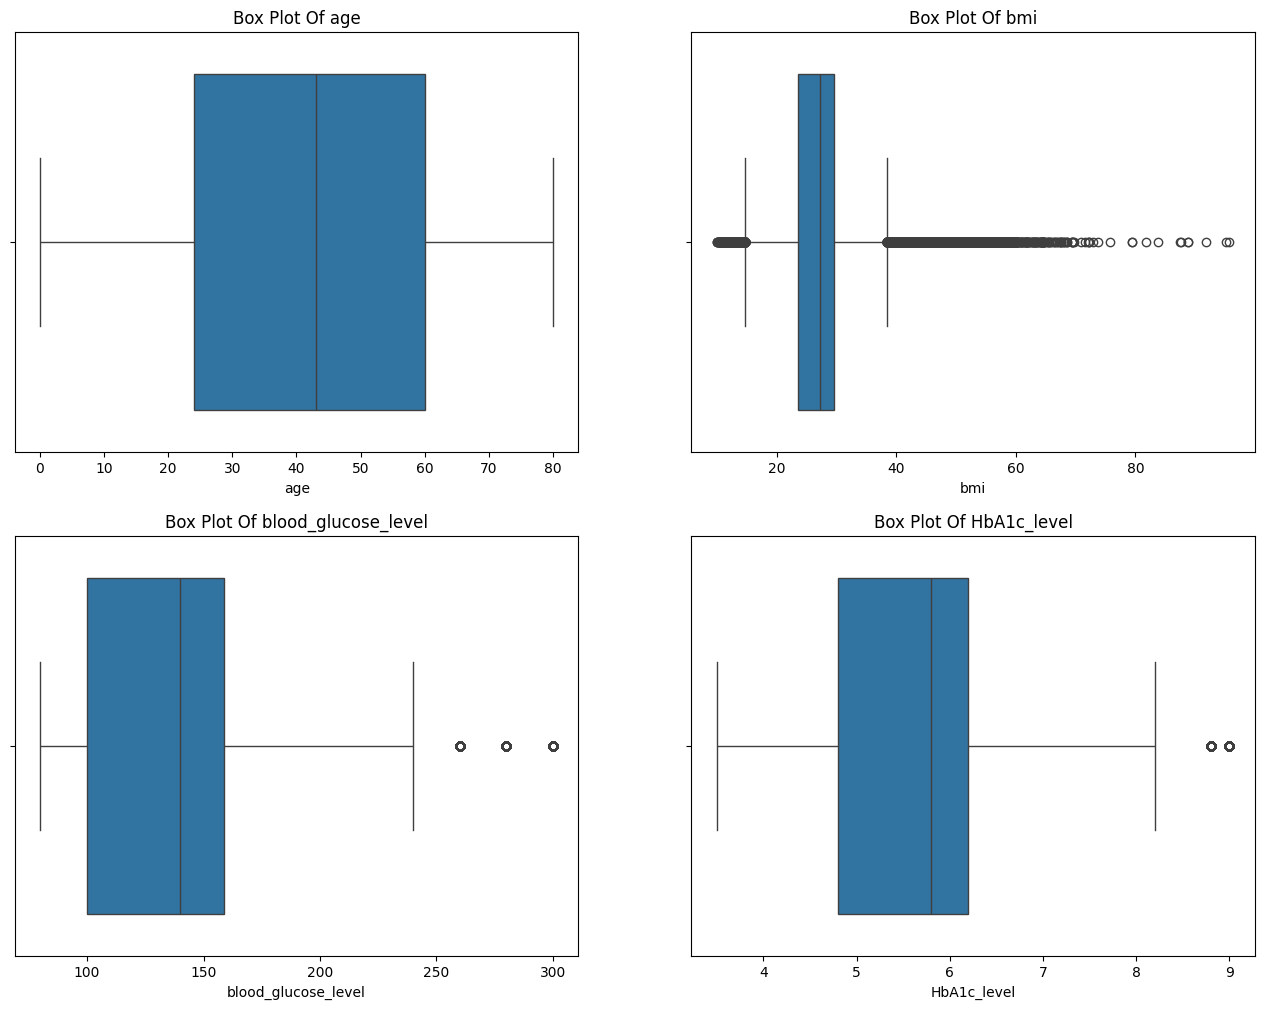

<Figure size 640x480 with 0 Axes>

In [14]:
fig, axs=plt.subplots(2,2, figsize=(16,12))
axs=axs.flatten()
for i, col in enumerate(num_cat):
    sns.boxplot(data=Diabetes_df, x=col, ax=axs[i])
    axs[i].set_title(f'Box Plot Of {col}')
    axs[i].set_xlabel(col)

plt.show()
plt.tight_layout()

### Visualization of Diabetes Status vs Medical Data

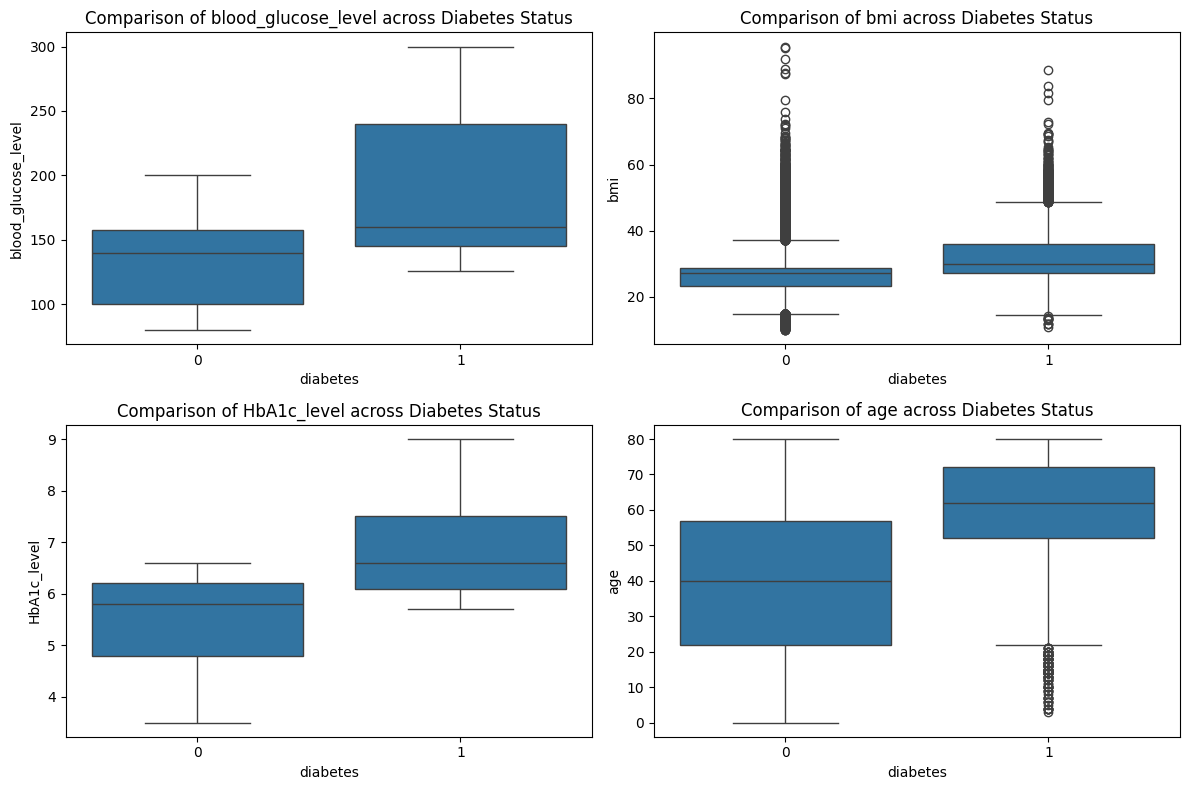

In [15]:
glucose=['blood_glucose_level','bmi','HbA1c_level','age']

fig, axs=plt.subplots(2,2, figsize=(12,8))
axs=axs.flatten()
for i, col in enumerate(glucose):
    sns.boxplot(data=Diabetes_df, x='diabetes', y=col, ax=axs[i])
    axs[i].set_title(f'Comparison of {col} across Diabetes Status')

plt.tight_layout()
plt.show()

### Visualization Of Hypertension Status VS Medical Data

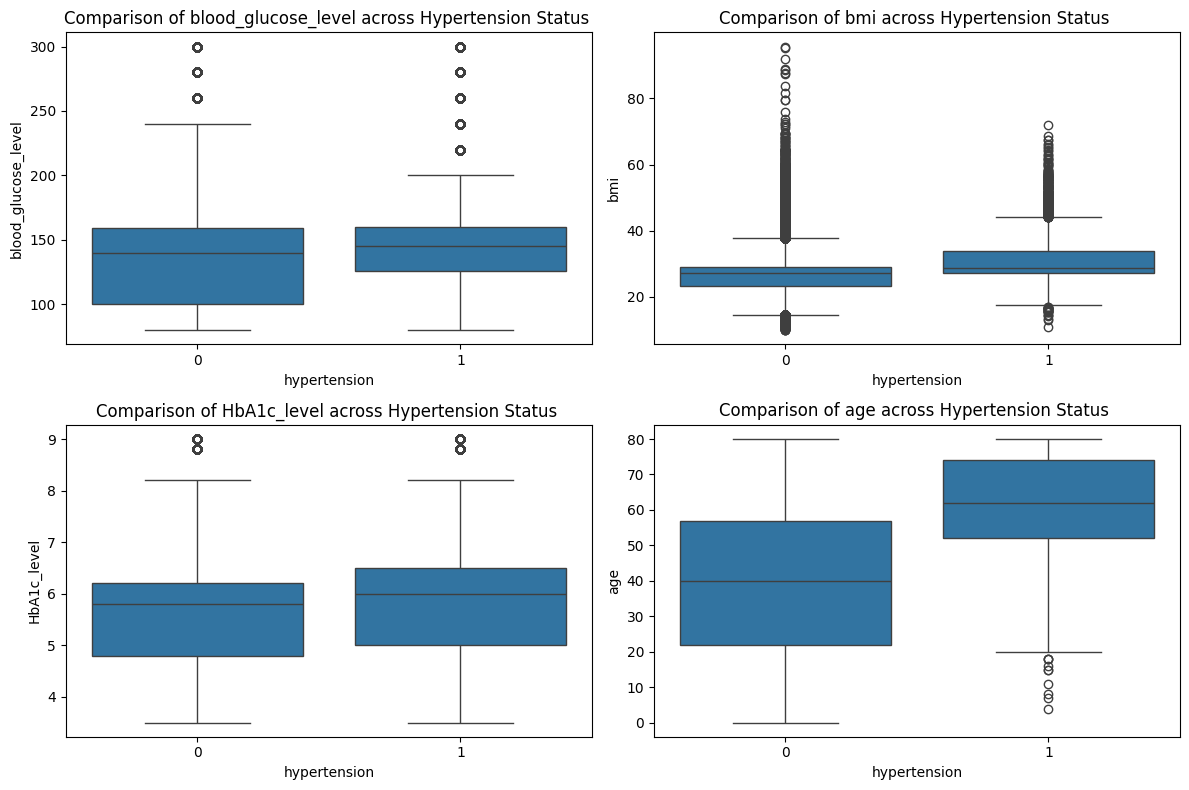

In [16]:
fig, axs=plt.subplots(2,2, figsize=(12,8))
axs=axs.flatten()

for i, col in enumerate(glucose):
    sns.boxplot(data=Diabetes_df, x='hypertension', y=col, ax=axs[i])
    axs[i].set_title(f'Comparison of {col} across Hypertension Status ')

plt.tight_layout()
plt.show()


### Visualization of Heart Disease Status VS Medical Data

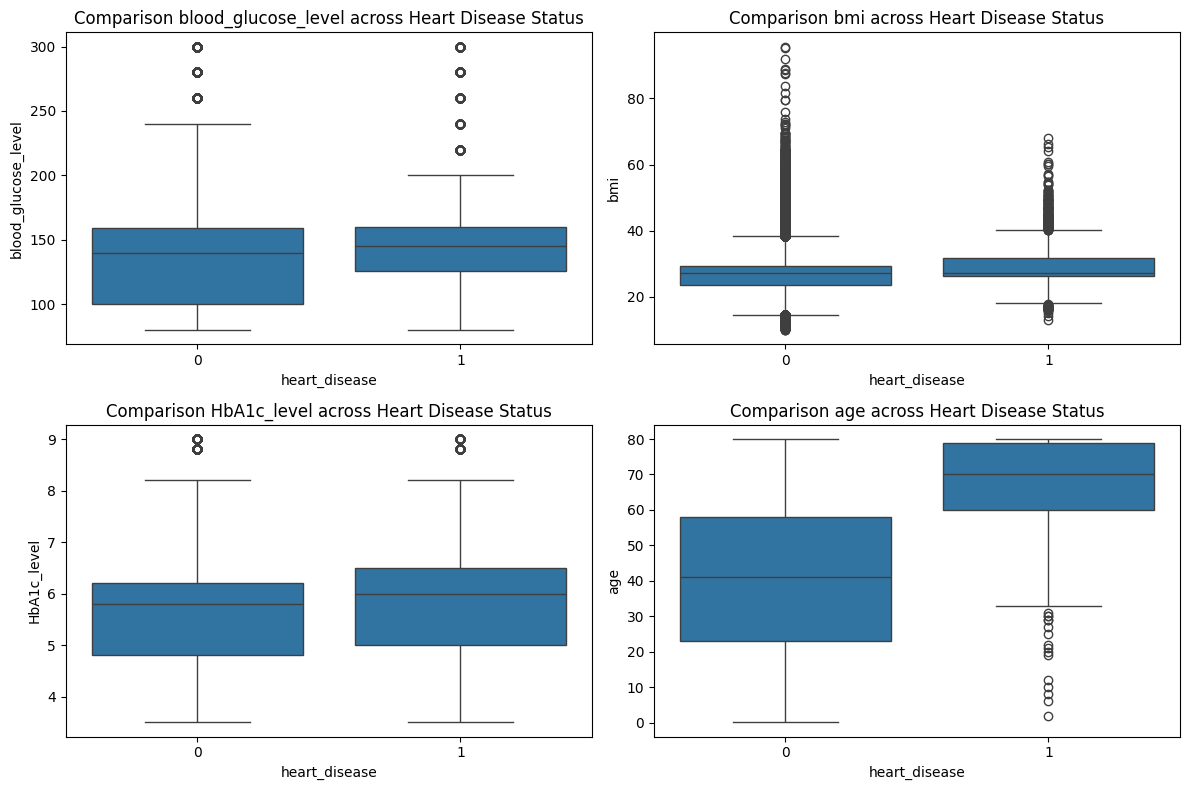

In [17]:
fig, axs=plt.subplots(2,2 , figsize=(12,8))
axs=axs.flatten()

for i, col in enumerate(glucose):
    sns.boxplot(data=Diabetes_df, x='heart_disease', y=col, ax=axs[i])
    axs[i].set_title(f'Comparison {col} across Heart Disease Status')

plt.tight_layout()
plt.show()

### Visualization of Smoking History VS Gender

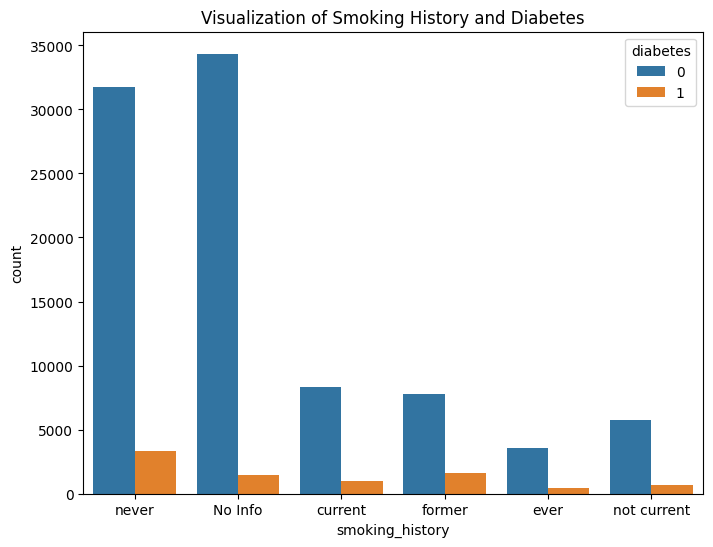

In [18]:
plt.figure(figsize=(8,6))
sns.countplot(data=Diabetes_df, x='smoking_history', hue='diabetes')
plt.title('Visualization of Smoking History and Diabetes')
plt.show()

### Visualization of Diabetes Status VS Hypertension Status

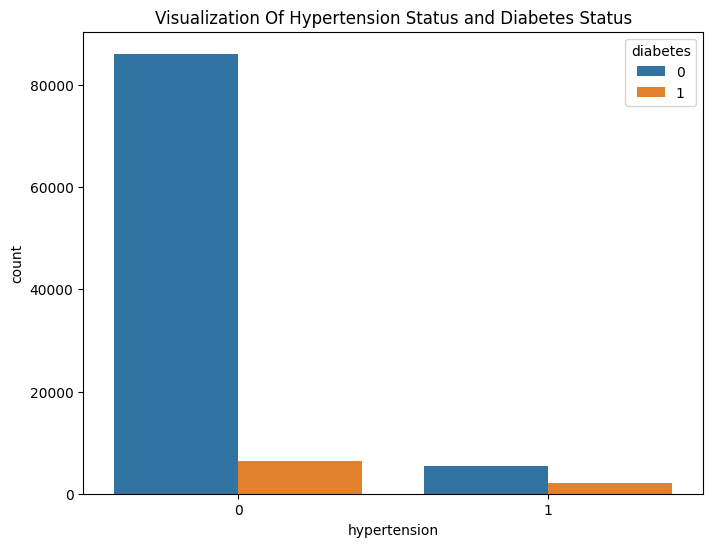

In [19]:
plt.figure(figsize=(8,6))
sns.countplot(data=Diabetes_df, x='hypertension', hue='diabetes')
plt.title('Visualization Of Hypertension Status and Diabetes Status')
plt.show()

### Visualization of Heart Disease Status VS Diabetes Status

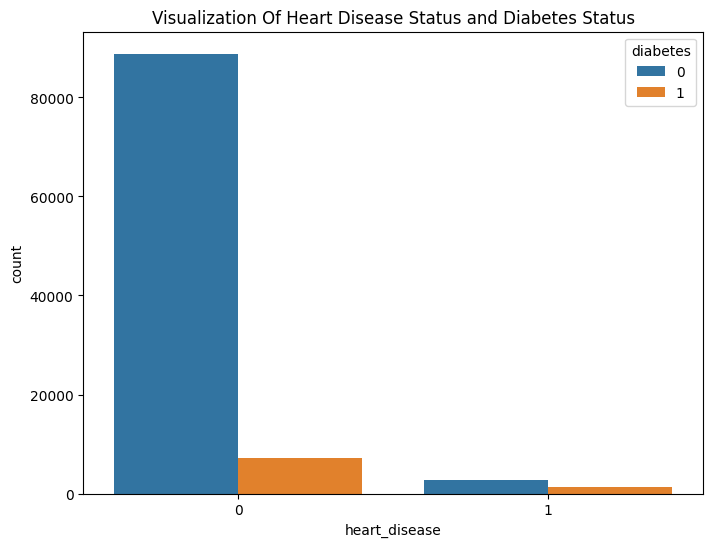

In [20]:
plt.figure(figsize=(8,6))
sns.countplot(data=Diabetes_df, x='heart_disease', hue='diabetes')
plt.title('Visualization Of Heart Disease Status and Diabetes Status')
plt.show()

### Heatmap of Medical Data

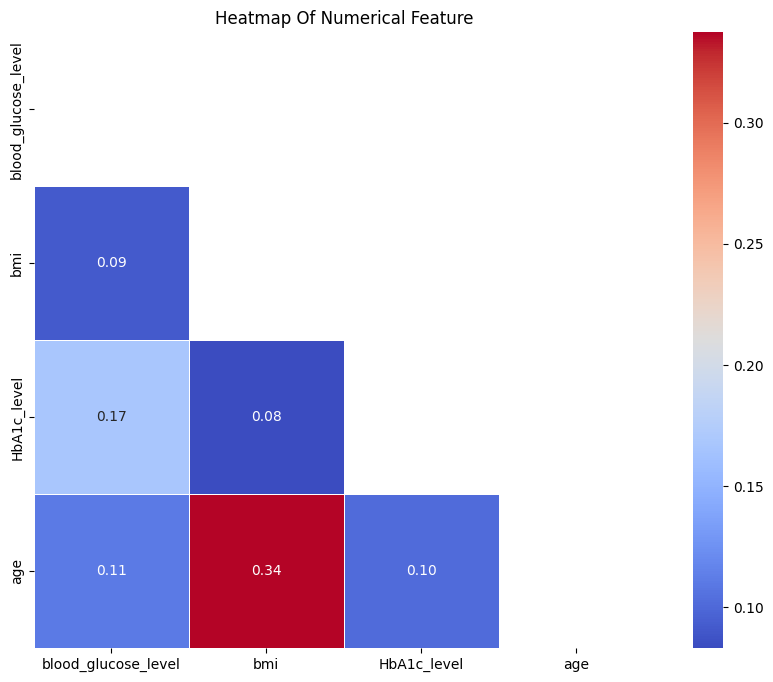

In [21]:
num_column=Diabetes_df[['blood_glucose_level','bmi','HbA1c_level','age']]
corr_num=num_column.corr()
mask=np.triu(np.ones_like(corr_num, dtype=bool))
plt.figure(figsize=(10,8))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', linewidths=0.5, mask=mask, fmt='.2f' )
plt.title('Heatmap Of Numerical Feature')
plt.show()

# Preprocessing

## Mismatch Data Handling

In [22]:
Diabetes_df[Diabetes_df.age <1].age.value_counts()

,count
age,
0.72,104
0.80,102
0.64,99
0.56,96
0.88,90
0.32,89
0.24,87
0.48,83
0.40,66


In [23]:
Diabetes_df.loc[Diabetes_df.age <1, 'age']=Diabetes_df.loc[Diabetes_df.age <1, 'age'] *100

In [24]:
Diabetes_df[Diabetes_df.age <1].age.value_counts()

,count
age,


In [25]:
Diabetes_df=Diabetes_df.drop_duplicates()

In [26]:
Diabetes_df.shape

(96121, 9)

In [27]:
Diabetes_df=Diabetes_df[Diabetes_df['gender'] !='Other']

## Duplicate Data Handling

In [28]:
Duplicate=Diabetes_df.duplicated().sum()
print("Duplicate Data In Dataframe:", Duplicate)

Duplicate Data In Dataframe: 0


## Outlier Handling

In [29]:
def outlier_handling(df, columns):
    df_cleaned=df.copy()
    for col in columns:
        if pd.api.types.is_numeric_dtype(df_cleaned[col]):
            Q1=df_cleaned[col].quantile(0.25)
            Q3=df_cleaned[col].quantile(0.75)
            IQR=Q3-Q1
            lower_bound=Q1- 1.5 * IQR
            upper_bound= Q3 + 1.5 * IQR
            df_cleaned=df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    df_cleaned=df_cleaned.reset_index(drop=True)
    return df_cleaned

Diabetes_df=outlier_handling(Diabetes_df, columns=['blood_glucose_level','bmi','age','HbA1c_level'])

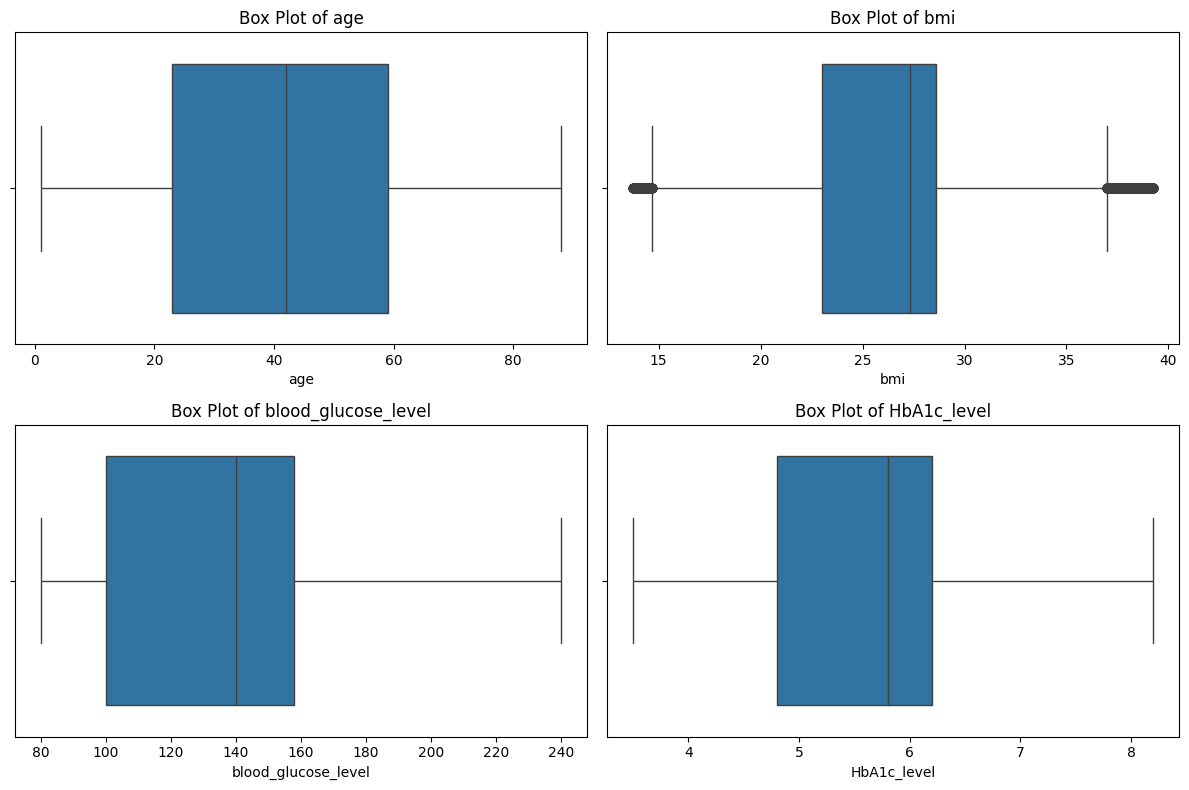

In [30]:
fig, axs=plt.subplots(2,2, figsize=(12,8))
axs=axs.flatten()

for i, col in enumerate(num_cat):
    sns.boxplot(data=Diabetes_df, x=Diabetes_df[col], ax=axs[i])
    axs[i].set_title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

## Encodode

In [31]:
gender_encode={
    'Male':0,
    'Female':1
}
smoking_encode={
    'never':0,
    'not current':1,
    'former':2,
    'current':3,
    'ever':4,
    'No Info':5
}
Diabetes_df['gender']=Diabetes_df['gender'].map(gender_encode)
Diabetes_df['smoking_history']=Diabetes_df['smoking_history'].map(smoking_encode)
Diabetes_df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,80.0,0,1,0,25.19,6.6,140,0
1,1,54.0,0,0,5,27.32,6.6,80,0
2,0,28.0,0,0,0,27.32,5.7,158,0
3,1,36.0,0,0,3,23.45,5.0,155,0
4,0,76.0,1,1,3,20.14,4.8,155,0


## Dataset balancing technique: Oversample

In [32]:
diabetes_df_majority=Diabetes_df[Diabetes_df['diabetes']==0]
diabetes_df_minority=Diabetes_df[Diabetes_df['diabetes']==1]

diabetes_df_minority_oversample=resample(
    diabetes_df_minority,
    replace=True,
    n_samples=len(diabetes_df_majority),
    random_state=42
)
Diabetes_df=pd.concat([diabetes_df_majority, diabetes_df_minority_oversample])
Diabetes_df=Diabetes_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [33]:
Diabetes_df['diabetes'].value_counts()

,count
diabetes,
1,83302
0,83302


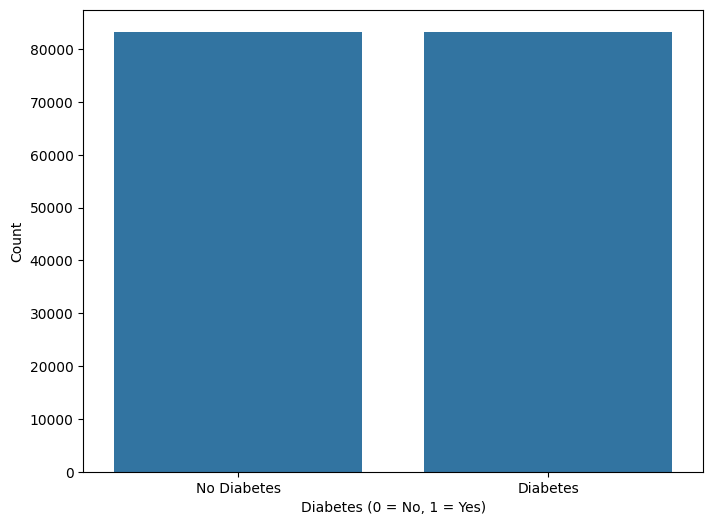

In [34]:
plt.figure(figsize=(8,6))

sns.countplot(data=Diabetes_df, x='diabetes')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [35]:
Diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166604 entries, 0 to 166603
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               166604 non-null  int64  
 1   age                  166604 non-null  float64
 2   hypertension         166604 non-null  int64  
 3   heart_disease        166604 non-null  int64  
 4   smoking_history      166604 non-null  int64  
 5   bmi                  166604 non-null  float64
 6   HbA1c_level          166604 non-null  float64
 7   blood_glucose_level  166604 non-null  int64  
 8   diabetes             166604 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 11.4 MB


## Feature Selection

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from math import log2


In [37]:

# --- ENTROPY FUNCTION ---
def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return -np.sum(probabilities * np.log2(probabilities))

# --- INFORMATION GAIN ---
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    values, counts = np.unique(data[feature], return_counts=True)
    weighted_entropy = np.sum([
        (counts[i] / np.sum(counts)) * entropy(data[data[feature] == values[i]][target])
        for i in range(len(values))
    ])
    return total_entropy - weighted_entropy

# --- GAIN RATIO ---
def gain_ratio(data, feature, target):
    ig = information_gain(data, feature, target)
    values, counts = np.unique(data[feature], return_counts=True)
    probabilities = counts / np.sum(counts)
    intrinsic_value = -np.sum(probabilities * np.log2(probabilities))
    if intrinsic_value == 0:
        return 0
    return ig / intrinsic_value

# --- CALCULATE FOR ALL FEATURES ---
target = 'diabetes'
info_gain_results = {}
gain_ratio_results = {}

for feature in Diabetes_df.columns:
    if feature != target:
        info_gain_results[feature] = information_gain(Diabetes_df, feature, target)
        gain_ratio_results[feature] = gain_ratio(Diabetes_df, feature, target)

# --- CREATE RESULT DATAFRAME ---
ig_df = pd.DataFrame({
    'Feature': list(info_gain_results.keys()),
    'Information Gain': list(info_gain_results.values()),
    'Gain Ratio': list(gain_ratio_results.values())
}).sort_values(by='Information Gain', ascending=False)

print(ig_df)



               Feature  Information Gain  Gain Ratio
6          HbA1c_level          0.388717    0.099408
7  blood_glucose_level          0.300005    0.078739
1                  age          0.212672    0.034956
5                  bmi          0.202521    0.021999
2         hypertension          0.051663    0.084068
4      smoking_history          0.042482    0.018850
3        heart_disease          0.035332    0.079877
0               gender          0.004554    0.004581


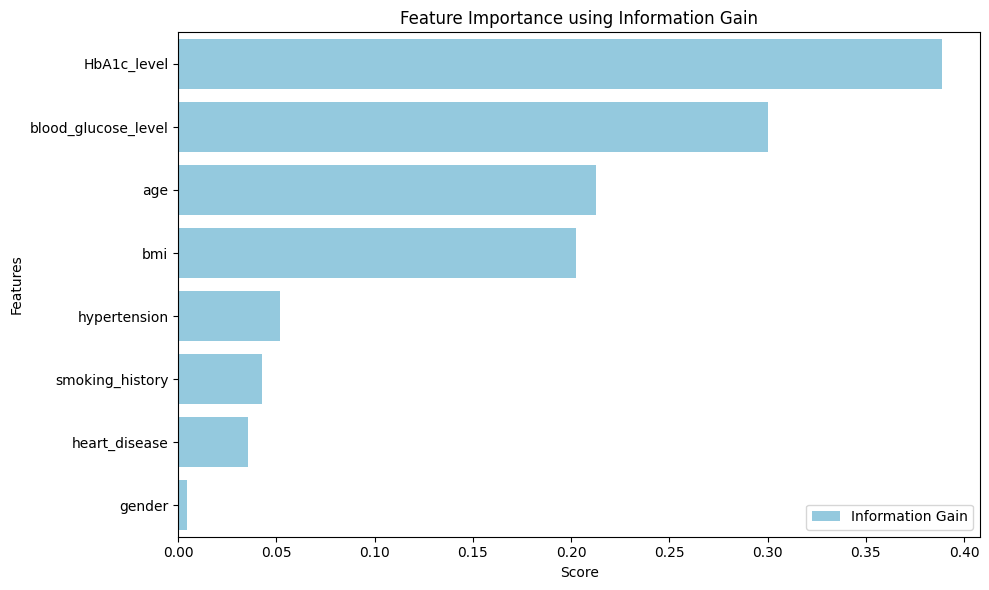

In [38]:
# --- VISUALIZATION ---
plt.figure(figsize=(10,6))
sns.barplot(x='Information Gain', y='Feature', data=ig_df, color='skyblue', label='Information Gain')
plt.title('Feature Importance using Information Gain')
plt.xlabel('Score')
plt.ylabel('Features')
plt.legend()
plt.tight_layout()
plt.show()


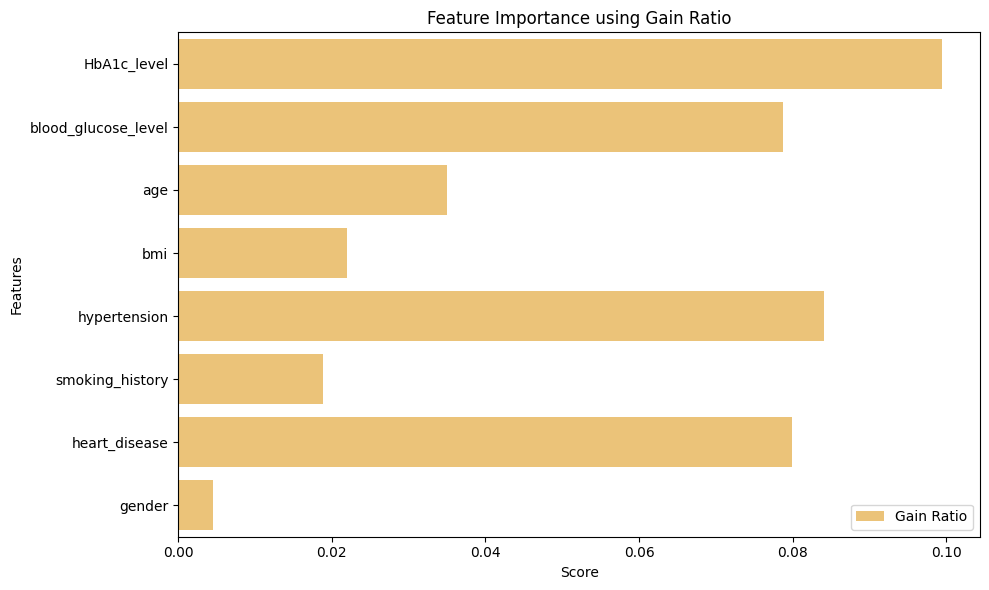

In [39]:
# --- VISUALIZATION ---
plt.figure(figsize=(10,6))
sns.barplot(x='Gain Ratio', y='Feature', data=ig_df, color='orange', alpha=0.6, label='Gain Ratio')
plt.title('Feature Importance using Gain Ratio')
plt.xlabel('Score')
plt.ylabel('Features')
plt.legend()
plt.tight_layout()
plt.show()


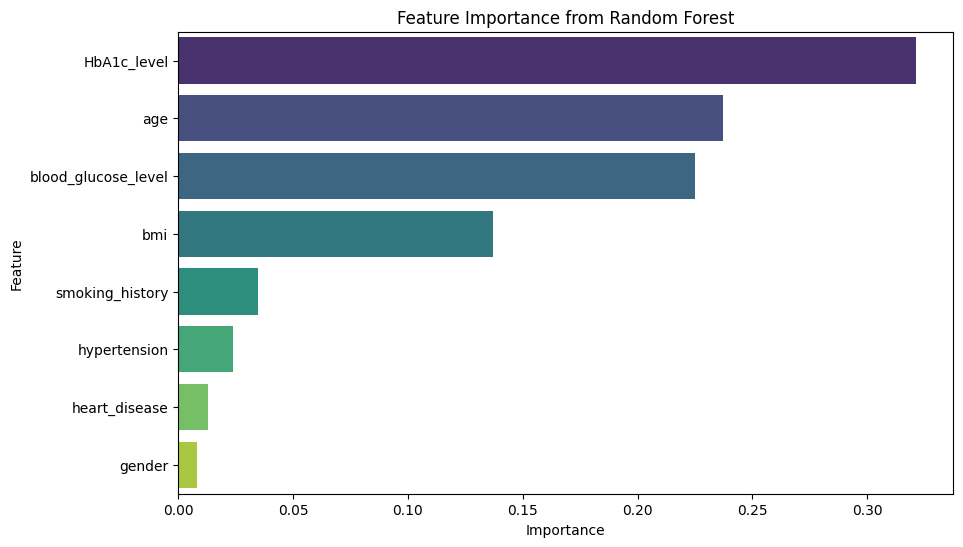

In [40]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Separate features and target
X = Diabetes_df.drop('diabetes', axis=1)
y = Diabetes_df['diabetes']

# Train Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Get feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.show()


In [41]:
Diabetes_df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

## Hybrid Feature Selection

In [42]:
y.value_counts()

,count
diabetes,
1,83302
0,83302


In [43]:
from sklearn.model_selection import train_test_split

# Select 10,000 stratified samples
X_train_sampled, _, y_train_sampled, _ = train_test_split(X, y,
                                                          train_size=10000,
                                                          stratify=y,
                                                          random_state=42)

print(f'Sampled Training Data Shape: X_train_sampled {X_train_sampled.shape}, y_train_sampled{y_train_sampled.shape}')

Sampled Training Data Shape: X_train_sampled (10000, 8), y_train_sampled(10000,)


Optimal number of features : 8
Selected features (RFECV) : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']


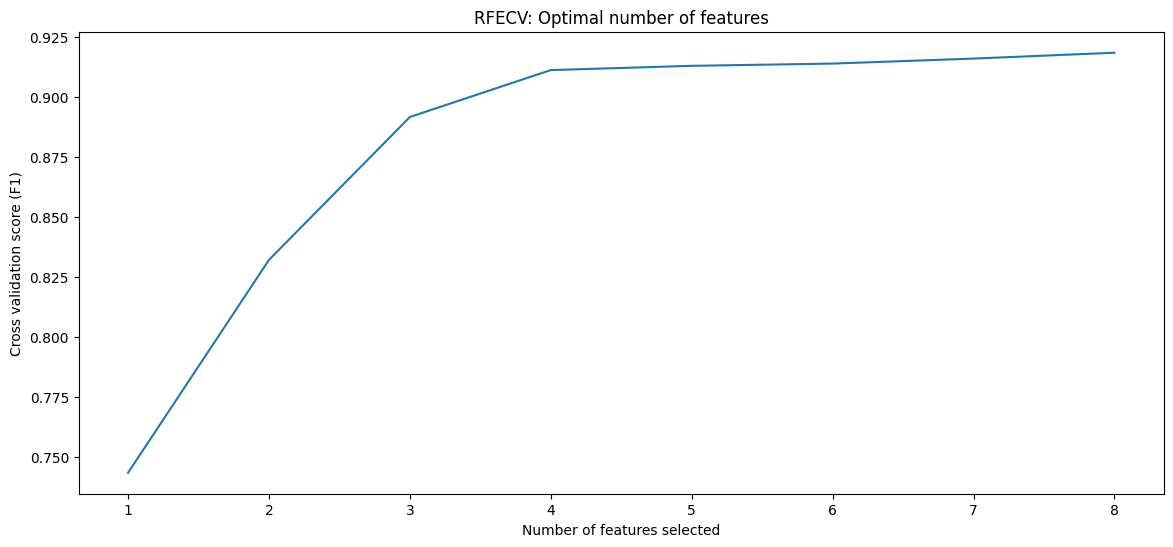

In [44]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Initialize the estimator (Random Forest is a good choice for feature selection)
estimator = RandomForestClassifier(random_state=42)

# Initialize RFECV with the estimator, cross-validation strategy, and scoring metric
rfecv = RFECV(estimator=estimator, step=1, cv=StratifiedKFold(3), scoring='f1', n_jobs=-1)

# Fit RFECV to the training data
rfecv.fit(X_train_sampled, y_train_sampled)

# Get the selected features
selected_features_rfecv = X_train_sampled.columns[rfecv.support_]

print("Optimal number of features : %d" % rfecv.n_features_)
print("Selected features (RFECV) :", list(selected_features_rfecv))

# Plot number of features vs. cross-validation score
plt.figure(figsize=(14, 6))
plt.title('RFECV: Optimal number of features')
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (F1)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.show()

## Split Data Train and Data Test

In [45]:
# Update X and X_test with the features selected by RFECV
X = Diabetes_df[selected_features_rfecv]
X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=0.2, random_state=42)

print(f'Training Data Shape after RFECV: X_train {X_train.shape}, y_train{y_train.shape}')
print(f'Testing Data Shape after RFECV: X_test {X_test.shape}, y_test {y_test.shape}')

Training Data Shape after RFECV: X_train (133283, 8), y_train(133283,)
Testing Data Shape after RFECV: X_test (33321, 8), y_test (33321,)


Now that we have the features selected using RFECV, we can proceed with modeling using the updated `X_train`, `X_test`, `y_train`, and `y_test` datasets.

# Modelling

## Random Forest

In [46]:
y_train.value_counts()

,count
diabetes,
1,66642
0,66641


In [47]:
from sklearn.model_selection import train_test_split

# Select 10,000 stratified samples
X_train_sampled, _, y_train_sampled, _ = train_test_split(X_train, y_train,
                                                          train_size=10000,
                                                          stratify=y_train,
                                                          random_state=42)

print(f'Sampled Training Data Shape: X_train_sampled {X_train_sampled.shape}, y_train_sampled{y_train_sampled.shape}')

Sampled Training Data Shape: X_train_sampled (10000, 8), y_train_sampled(10000,)


### Hyperparameter Tuning

In [48]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=2, # Reduced to 2-fold cross-validation
                           scoring='f1', # Use F1 score as the evaluation metric
                           n_jobs=-1, # Use all available cores
                           verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_sampled, y_train_sampled)

# Get the best parameters and the best estimator
best_params_rf = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

print("Best Parameters for Random Forest:", best_params_rf)

Fitting 2 folds for each of 24 candidates, totalling 48 fits
Best Parameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [49]:
Rf=RandomForestClassifier(**best_params_rf).fit(X_train, y_train)
eval_rf=Rf.predict(X_test)

acc_rf=accuracy_score(eval_rf, y_test)
precision_rf=precision_score(eval_rf, y_test)
recall_rf=recall_score(eval_rf, y_test)
f1_rf=f1_score(eval_rf, y_test)

In [50]:
result_df=({
    "Accuracy":[acc_rf],
    "Precisious":[precision_rf],
    "Recall":[recall_rf],
    "F1 Score":[f1_rf]
})
result_df=pd.DataFrame(result_df, index=['Random Forest'])
result_df

,Accuracy,Precisious,Recall,F1 Score
Random Forest,0.977222,1.0,0.956427,0.977728


## Logistic Regression

In [51]:
Lg=LogisticRegression(max_iter=1000).fit(X_train, y_train)
eval_lg=Lg.predict(X_test)

acc_lg=accuracy_score(eval_lg, y_test)
precision_lg=precision_score(eval_lg,y_test)
recall_lg=recall_score(eval_lg, y_test)
f1_lg=f1_score(eval_lg, y_test)

In [52]:
result_df.loc['Logistic Regression']=[acc_lg, precision_lg, recall_lg, f1_lg]
result_df

,Accuracy,Precisious,Recall,F1 Score
Random Forest,0.977222,1.00000,0.956427,0.977728
Logistic Regression,0.859128,0.87605,0.847364,0.861469


## Decision Tree

In [53]:
Dt=DecisionTreeClassifier().fit(X_train, y_train)
eval_dt=Dt.predict(X_test)

acc_dt=precision_score(eval_dt, y_test)
precision_dt=precision_score(eval_dt, y_test)
recall_dt=recall_score(eval_dt, y_test)
f1_dt=f1_score(eval_dt, y_test)

In [54]:
result_df.loc['Decision Tree']=[acc_dt, precision_dt, recall_dt, f1_dt]
result_df

,Accuracy,Precisious,Recall,F1 Score
Random Forest,0.977222,1.00000,0.956427,0.977728
Logistic Regression,0.859128,0.87605,0.847364,0.861469
Decision Tree,1.000000,1.00000,0.970749,0.985158


## KNN

In [55]:
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
eval_knn = knn.predict(X_test)

acc_knn = accuracy_score(eval_knn, y_test)
precision_knn = precision_score(eval_knn, y_test)
recall_knn = recall_score(eval_knn, y_test)
f1_knn = f1_score(eval_knn, y_test)

result_df.loc['KNN'] = [acc_knn, precision_knn, recall_knn, f1_knn]

In [56]:
result_df

,Accuracy,Precisious,Recall,F1 Score
Random Forest,0.977222,1.00000,0.956427,0.977728
Logistic Regression,0.859128,0.87605,0.847364,0.861469
Decision Tree,1.000000,1.00000,0.970749,0.985158
KNN,0.957684,1.00000,0.921970,0.959401


## GradientBoost

In [57]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5).fit(X_train, y_train)
eval_gb = gb.predict(X_test)

acc_gb = accuracy_score(eval_gb, y_test)
precision_gb = precision_score(eval_gb, y_test)
recall_gb = recall_score(eval_gb, y_test)
f1_gb = f1_score(eval_gb, y_test)

In [58]:
result_df.loc['Gradient Boosting'] = [acc_gb, precision_gb, recall_gb, f1_gb]
result_df

,Accuracy,Precisious,Recall,F1 Score
Random Forest,0.977222,1.00000,0.956427,0.977728
Logistic Regression,0.859128,0.87605,0.847364,0.861469
Decision Tree,1.000000,1.00000,0.970749,0.985158
KNN,0.957684,1.00000,0.921970,0.959401
Gradient Boosting,0.914768,0.95048,0.887115,0.917705


## Xgboost

In [59]:
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss').fit(X_train, y_train)
eval_xgb = xgb_model.predict(X_test)

acc_xgb = accuracy_score(eval_xgb, y_test)
precision_xgb = precision_score(eval_xgb, y_test)
recall_xgb = recall_score(eval_xgb, y_test)
f1_xgb = f1_score(eval_xgb, y_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:12:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [60]:
result_df.loc['XGBoost'] = [acc_xgb, precision_xgb, recall_xgb, f1_xgb]
result_df

,Accuracy,Precisious,Recall,F1 Score
Random Forest,0.977222,1.000000,0.956427,0.977728
Logistic Regression,0.859128,0.876050,0.847364,0.861469
Decision Tree,1.000000,1.000000,0.970749,0.985158
KNN,0.957684,1.000000,0.921970,0.959401
Gradient Boosting,0.914768,0.950480,0.887115,0.917705
XGBoost,0.908886,0.946759,0.880092,0.912209


In [61]:
import pickle

# --- 1. Find the best model based on F1 Score ---
best_model_name = result_df['F1 Score'].idxmax()
print(f"Best Model based on F1 Score: {best_model_name}")

# --- 2. Map model name to the trained model object ---
models_dict = {
    'Random Forest': Rf,
    'Logistic Regression': Lg,
    'Decision Tree': Dt,
    'KNN': knn,
    'Gradient Boosting': gb,
    'XGBoost': xgb_model
}

best_model = models_dict[best_model_name]


best_model_name

Best Model based on F1 Score: Decision Tree


'Decision Tree'

In [62]:
# --- 3. Save the best model as a pickle file ---
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"{best_model_name} has been saved as 'best_model.pkl'.")

Decision Tree has been saved as 'best_model.pkl'.


## Model Perfomance Comparison

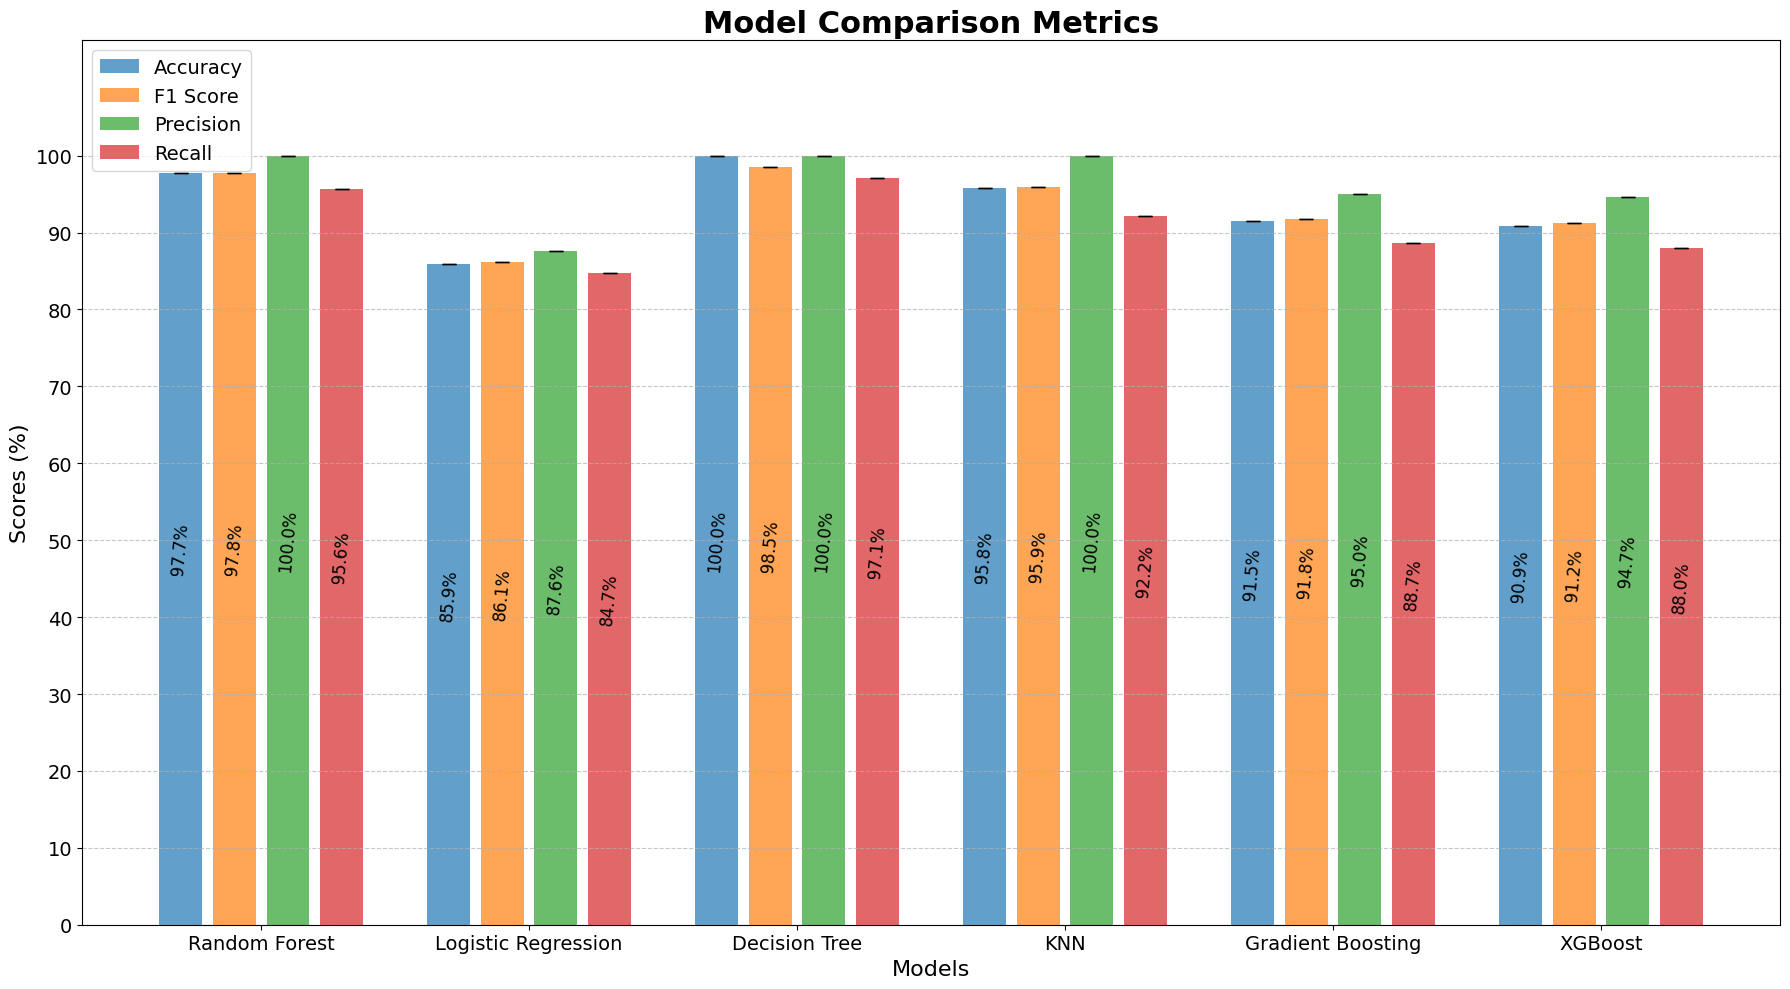

In [63]:
# --- 1. Prepare data ---
models = result_df.index.tolist()

# Extract metrics as percentages
accuracy = result_df['Accuracy'].values * 100
f1_scores = result_df['F1 Score'].values * 100
precision = result_df['Precisious'].values * 100
recall = result_df['Recall'].values * 100

# Optional: set errors to zero (or you can compute if you have cross-validation)
error_accuracies = np.zeros(len(models))
error_f1_scores = np.zeros(len(models))
error_precisions = np.zeros(len(models))
error_recalls = np.zeros(len(models))

metrics = [accuracy, f1_scores, precision, recall]
metrics_labels = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
metrics_errors = [error_accuracies, error_f1_scores, error_precisions, error_recalls]

# --- 2. Bar chart setup ---
x_pos = np.arange(len(models))
width = 0.2  # Width of each bar

fig, ax = plt.subplots(figsize=(18, 10))  # Adjust size as needed

# --- 3. Plot grouped bars with optional error bars ---
for i, (metric, label, errors) in enumerate(zip(metrics, metrics_labels, metrics_errors)):
    bar = ax.bar(
        x_pos + i * width, metric, width * 0.8, yerr=errors,
        label=label, alpha=0.7, ecolor='black', capsize=5
    )

    # Add labels inside bars
    for j, (rect, value) in enumerate(zip(bar, metric)):
        height = rect.get_height()
        offset_x = rect.get_x() + rect.get_width() / 2.0
        offset_y = height * 0.5

        if value == 0.0:
            ax.text(offset_x, 1, f'{value:.1f}%', ha='center', va='center', fontsize=12, color='black')
        else:
            ax.text(offset_x, offset_y, f'{value:.1f}%', ha='center', va='center', fontsize=12, color='black', rotation=85)

# --- 4. Styling ---
ax.set_title('Model Comparison Metrics', fontsize=22, weight='bold')
ax.set_xlabel('Models', fontsize=16)
ax.set_ylabel('Scores (%)', fontsize=16)
ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels(models, ha='center', fontsize=14)
ax.set_ylim(0, 115)
ax.set_yticks(np.arange(0, 110, 10))
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=14, loc='upper left')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# --- 5. Layout and save ---
plt.tight_layout()
plt.savefig('Model_Comparison_Metrics.pdf', bbox_inches='tight')
plt.show()

# Best model selection and save

In [64]:
import pickle

# Find the best model based on F1 Score
best_model_name = result_df['F1 Score'].idxmax()
print(f"Best Model based on F1 Score: {best_model_name}")

# Map model name to the trained model object
models_dict = {
    'Random Forest': Rf,
    'Logistic Regression': Lg,
    'Decision Tree': Dt,
    'KNN': knn,
    'Gradient Boosting': gb,
    'XGBoost': xgb_model
}

best_model = models_dict[best_model_name]

Best Model based on F1 Score: Decision Tree


In [65]:
# Save the best model as a pickle file
with open('best_model.pkl', 'wb') as f:
    pickle.dump(Rf, f)

print(f"{best_model_name} has been saved as 'best_model.pkl'.")

Decision Tree has been saved as 'best_model.pkl'.


# Deploy

In [86]:
import os

# Create the deployment directory if it doesn't exist
deploy_dir = 'diabetes_api'
if not os.path.exists(deploy_dir):
    os.makedirs(deploy_dir)
    print(f"Directory '{deploy_dir}' created.")
else:
    print(f"Directory '{deploy_dir}' already exists.")

Directory 'diabetes_api' already exists.


### 1. Install Uvicorn and FastAPI

These are the libraries required to run your FastAPI application.

In [87]:
!pip install uvicorn fastapi pyngrok

### 2. Start the FastAPI Server

We'll use `uvicorn` to run the `main.py` application. Since Colab notebooks run on a remote server, we'll use `pyngrok` to create a public URL that allows you to access your API from outside the Colab environment. This will expose your FastAPI server running on port `8000` through a public URL.

In [92]:
import subprocess
import threading
import time
import os
import shutil # Added for shutil.copy
from pyngrok import ngrok

# --- Ensure deployment directory and files exist ---
deploy_dir = 'diabetes_api'
if not os.path.exists(deploy_dir):
    os.makedirs(deploy_dir)
    print(f"Directory '{deploy_dir}' recreated.")

# Re-create main.py in case it was lost
main_py_content = """
from fastapi import FastAPI
import joblib
import numpy as np
import pandas as pd

app = FastAPI()
model = joblib.load("best_model.pkl")

@app.get("/")
def home():
    return {"msg": "Diabetes prediction API running"}

@app.post("/predict")
def predict(data: list):
    data_array = np.array(data).reshape(1, -1)
    result = model.predict(data_array)[0]
    return {"prediction": int(result)}
"""
with open(os.path.join(deploy_dir, 'main.py'), 'w') as f:
    f.write(main_py_content)

# Re-copy the model in case it was lost
model_source = 'best_model.pkl'
if os.path.exists(model_source):
    shutil.copy(model_source, deploy_dir)
    print(f"'{model_source}' copied to '{deploy_dir}'.")
else:
    print(f"Warning: '{model_source}' not found. Please ensure the model exists in the root directory.")

# Kill any running ngrok tunnels
ngrok.kill()

# Define the port your FastAPI app will run on
PORT = 8000

# Start uvicorn in a separate thread
def start_uvicorn():
    os.chdir(deploy_dir) # Change to the directory where main.py is located
    try:
        subprocess.run(["uvicorn", "main:app", "--host", "0.0.0.0", "--port", str(PORT)], check=True)
    except Exception as e:
        print(f"Uvicorn process failed: {e}")
    finally:
        os.chdir('..') # Change back to the original directory

uvicorn_thread = threading.Thread(target=start_uvicorn)
uvicorn_thread.daemon = True # Daemon threads exit when the main program exits
uvicorn_thread.start()

time.sleep(5) # Give uvicorn a moment to start

# Setup ngrok tunnel
# IMPORTANT: Your ngrok authtoken is now inserted here.
# You can get one from https://ngrok.com/signup -> Your Authtoken
my_ngrok_token = "35t16IFM8NE6EItStxEAZ7GPUHb_56nEuJZhq7NLMhcrdHrr4" # Your provided ngrok token is now set
print(f"Attempting to use ngrok token: {my_ngrok_token}") # Diagnostic print
ngrok.set_auth_token(my_ngrok_token)

try:
    tunnel = ngrok.connect(PORT)
    public_url = tunnel.public_url
    print(f"FastAPI app available at: {public_url}")
except Exception as e:
    print(f"ngrok failed to connect: {e}")
    print("Please ensure you have replaced 'YOUR_NGROK_AUTH_TOKEN' with a valid token.")

'best_model.pkl' copied to 'diabetes_api'.
Uvicorn process failed: Command '['uvicorn', 'main:app', '--host', '0.0.0.0', '--port', '8000']' returned non-zero exit status 1.
Attempting to use ngrok token: 35t16IFM8NE6EItStxEAZ7GPUHb_56nEuJZhq7NLMhcrdHrr4
FastAPI app available at: https://unnectareous-convictively-jeanette.ngrok-free.dev


### 3. Test the API

You can now use the `public_url` printed above to send requests to your FastAPI application. Here's an example using the `requests` library to send data to your `/predict` endpoint.

In [93]:
import requests

# Replace with the actual public URL from the previous cell output
# It should look something like: 'http://<random_string>.ngrok.io'
api_url = public_url # Use the public_url obtained from the ngrok tunnel

# Example data for prediction
# The order of features must match the order the model expects:
# ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
example_data = [
    1,    # gender (Female)
    55.0, # age
    0,    # hypertension
    0,    # heart_disease
    0,    # smoking_history (never)
    28.0, # bmi
    6.0,  # HbA1c_level
    120   # blood_glucose_level
]

# Make a POST request to the /predict endpoint
response = requests.post(f"{api_url}/predict", json=example_data)

# Print the response
if response.status_code == 200:
    print("Prediction successful:", response.json())
else:
    print("Error:", response.status_code, response.text)

Error: 422 {"detail":[{"type":"missing","loc":["body","data"],"msg":"Field required","input":null}]}


You can also visit the root URL (`{public_url}/`) in your browser to see the welcome message, or `{public_url}/docs` for the automatically generated OpenAPI documentation (Swagger UI) of your API.

In [94]:
import os

# Define the content for main.py
main_py_content = """
from fastapi import FastAPI
import joblib
import numpy as np
import pandas as pd # Added to handle potential DataFrame conversion if needed for model input

app = FastAPI()

# Load the best model
# Make sure 'best_model.pkl' is in the same directory as main.py
# Or provide the full path if it's elsewhere
model = joblib.load("best_model.pkl")

@app.get("/")
def home():
    return {"msg": "Diabetes prediction API running"}

@app.post("/predict")
def predict(data: list):
    # Convert the input list to a NumPy array for prediction
    data_array = np.array(data).reshape(1, -1) # Reshape for single prediction
    result = model.predict(data_array)[0]
    # The model expects feature names, so convert to DataFrame if the model was trained with one
    # if isinstance(model, (RandomForestClassifier, DecisionTreeClassifier, GradientBoostingClassifier, xgb.XGBClassifier)):
    #     # This part might need adjustment based on how the model expects features
    #     # For simplicity, assuming the model can handle a numpy array directly
    #     # If feature names are strictly required, you'd need to pass them or create a DataFrame
    #     pass

    return {"prediction": int(result)}
"""

# Write main.py to the deployment directory
with open(os.path.join(deploy_dir, 'main.py'), 'w') as f:
    f.write(main_py_content)
print(f"'{deploy_dir}/main.py' created.")

'diabetes_api/main.py' created.


In [95]:
import os

# Define the content for requirements.txt
requirements_txt_content = """
fastapi
uvicorn
joblib
numpy
pandas
scikit-learn
xgboost
matplotlib
seaborn
"""

# Write requirements.txt to the deployment directory
with open(os.path.join(deploy_dir, 'requirements.txt'), 'w') as f:
    f.write(requirements_txt_content)
print(f"'{deploy_dir}/requirements.txt' created.")

'diabetes_api/requirements.txt' created.


In [96]:
import shutil

# Define paths
model_source = 'best_model.pkl'
model_destination_dir = 'diabetes_api'

# Check if the model file exists in the current directory
if os.path.exists(model_source):
    # Copy the model to the deployment directory
    shutil.copy(model_source, model_destination_dir)
    print(f"'{model_source}' copied to '{model_destination_dir}'.")
else:
    print(f"Error: '{model_source}' not found in the current directory.")

'best_model.pkl' copied to 'diabetes_api'.
